## 4折交叉验证结果分析与可视化

本 Notebook 用于对4折交叉验证的结果进行统一分析。

主要步骤如下：
1. **配置路径**: 设置包含所有模型折（k1-k4）的基础路径和推理设备。
2. **加载模型**: 自动查找每个折文件夹下`validation_pearson`分数最高的模型权重，并一次性加载所有4个最佳模型到指定的GPU设备上。
3. **执行推理**: 对每一折，加载其对应的验证数据集，并使用相应的模型进行推理，收集所有真实值和预测值。
4. **计算总体相关性**: 将4折的所有结果汇总，计算一个总体的皮尔逊相关系数。
5. **可视化与保存**: 绘制一张散点图，其中用不同颜色区分每一折的数据点，并显示总体相关性。最后，将图表保存为 PNG 和 PDF 文件。

In [1]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import pearsonr
import glob
import trainUtils  # 确保 trainUtils.py 和 modules.py 在工作目录或Python路径中
import modules
import re

# 设置 Matplotlib 字体以支持在PDF中嵌入字体
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

### 1. 配置参数

In [2]:
# --- 用户配置区 ---
BASE_PATH = "/data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_CCK8/"
DEVICE = "cuda:7"  # 根据您的H800 GPU情况修改设备号，例如 "cuda:0"
OUTPUT_DIR = "figure_output/E_Mut/"
# ------------------

# 更新文件夹为 k1 到 k4
FOLDS = [f'k{i}' for i in range(1, 5)]

# 确保输出目录存在
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"模型基础路径: {BASE_PATH}")
print(f"将要处理的折: {FOLDS}")
print(f"将使用设备: {DEVICE}")
print(f"图表输出路径: {OUTPUT_DIR}")

模型基础路径: /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_CCK8/
将要处理的折: ['k1', 'k2', 'k3', 'k4']
将使用设备: cuda:7
图表输出路径: figure_output/E_Mut/


### 2. 加载所有模型

自动从每个折的文件夹中找到 `validation_pearson` 分数最高的`.ckpt`文件进行加载。

In [3]:
models = {}

for fold in tqdm(FOLDS, desc="Loading Models"):
    fold_path = os.path.join(BASE_PATH, fold)
    config_file = os.path.join(fold_path, "config.json")
    
    # 自动查找.ckpt文件
    checkpoint_files = glob.glob(os.path.join(fold_path, "*.ckpt"))
    if not checkpoint_files:
        raise FileNotFoundError(f"在路径 {fold_path} 中未找到 .ckpt 模型权重文件")
    
    # --- 新增逻辑：查找 validation_pearson_CCK8 最大的模型 ---
    best_checkpoint_file = None
    max_pearson = -float('inf')

    for ckpt_path in checkpoint_files:
        filename = os.path.basename(ckpt_path)
        # 使用正则表达式从文件名中提取 validation_pearson_CCK8 的值
        match = re.search(r'validation_pearson_CCK8=([0-9]+\.?[0-9]*)', filename)
        if match:
            pearson_val = float(match.group(1))
            if pearson_val > max_pearson:
                max_pearson = pearson_val
                best_checkpoint_file = ckpt_path
    
    if best_checkpoint_file is None:
        raise ValueError(f"在路径 {fold_path} 中未能找到符合命名格式 'validation_pearson_CCK8=...' 的有效 .ckpt 文件")
    # --- 结束 --- 

    checkpoint_file = best_checkpoint_file
    
    print(f"---\n正在加载 {fold} ...")
    print(f"  配置: {config_file}")
    print(f"  最佳权重: {os.path.basename(checkpoint_file)} (validation_pearson_CCK8={max_pearson:.4f})")
    
    with open(config_file, "r") as f:
        configs = json.load(f)
    
    pretrain_model = trainUtils.loadPretrainModel(configs)
    model = trainUtils.buildModel(configs, pretrain_model, checkpoint_file)
    
    model.eval()
    model.to(DEVICE)
    models[fold] = model

print("\n所有模型加载完毕!")

Loading Models:   0%|          | 0/4 [00:00<?, ?it/s]

---
正在加载 k1 ...
  配置: /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_CCK8/k1/config.json
  最佳权重: epoch=718-validation_pearson_CCK8=0.7221.ckpt (validation_pearson_CCK8=0.7221)
load local model: /data2/zhoukaitao/01evoModel/checkpoints/250813_stage1_test/pretrain_stage1_250824.pth
model at stage: training stage 1


/home/zhoukaitao/anaconda3/envs/esm3/lib/python3.10/site-packages/torch/nn/init.py:452: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


incompatible parameters ['stage_1_regressors.clf.3.weight', 'stage_1_regressors.clf.3.bias']
finish loading parameters
load model from checkpoint /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_CCK8/k1/epoch=718-validation_pearson_CCK8=0.7221.ckpt
---
正在加载 k2 ...
  配置: /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_CCK8/k2/config.json
  最佳权重: epoch=161-validation_pearson_CCK8=0.6244.ckpt (validation_pearson_CCK8=0.6244)
load local model: /data2/zhoukaitao/01evoModel/checkpoints/250813_stage1_test/pretrain_stage1_250824.pth
model at stage: training stage 1
incompatible parameters ['stage_1_regressors.clf.3.weight', 'stage_1_regressors.clf.3.bias']
finish loading parameters
load model from checkpoint /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_CCK8/k2/epoch=161-validation_pearson_CCK8=0.6244.ckpt
---
正在加载 k3 ...
  配置: /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_CCK8/k3/config.json
  最佳权重: epoch=188-validation_pearson_CCK8=0.6468.ck

### 3. 执行推理并收集数据

遍历每一折，使用对应的模型和验证集进行推理。

In [4]:
true_scores_by_fold = {}
predicted_scores_by_fold = {}

TYPE = "CCK8"

if TYPE == "CCK8":
    order=1
elif TYPE=="Activation":
    order=2
else:
    order=0


for fold in FOLDS:
    print(f"---\n正在处理 {fold} 的验证集...")
    model = models[fold]
    
    # 每次循环都需要根据对应折的config重新加载和设置数据集
    config_file = os.path.join(BASE_PATH, fold, "config.json")
    with open(config_file, "r") as f:
        configs = json.load(f)
        
    datasets = trainUtils.loadDataset(configs)
    datasets.setup(configs)  # 执行 train/val 分割
    val_dataloader = datasets.val_dataloader()
    val_dataset = val_dataloader.dataset
    val_dataset._sample = False
    print(f"{fold} 验证集包含 {len(val_dataset)} 个样本")

    fold_true_scores = []
    fold_predicted_scores = []

    for i in tqdm(range(len(val_dataset)), desc=f"Inferencing {fold}"):
        data_point = val_dataset[i]

        # a. 准备模型输入 (将numpy数组转为torch张量)
        model_input = {}
        for protein_name, protein_data in data_point['input'].items():
            if isinstance(protein_data, dict):
                model_input[protein_name] = {k: torch.tensor(v).unsqueeze(0).to(DEVICE) for k, v in protein_data.items()}
            else:
                model_input[protein_name] = torch.tensor(protein_data).unsqueeze(0).to(DEVICE)

        # b. 提取真实值
        true_fitness = data_point['label'][TYPE]
        fold_true_scores.append(true_fitness)

        # c. 模型推理
        with torch.no_grad():
            output = model(model_input)
        
        # d. 提取预测值
        
        protein_key = list(output.S1Predicts.keys())[0]
        predicted_fitness = output.S1Predicts[protein_key]['predictions'][0][order].item()
        fold_predicted_scores.append(predicted_fitness)
        
    true_scores_by_fold[fold] = fold_true_scores
    predicted_scores_by_fold[fold] = fold_predicted_scores

print("\n所有推理任务完成!")

Seed set to 1509


---
正在处理 k1 的验证集...
正在加载手动指定的验证集: /data2/zhoukaitao/01evoModel/dataset/250930_E_Mut/E_activate_fold/1_val.pkl
--- 手动指定验证集模式 ---
训练集: 62 个样本
验证集: 21 个样本
get val loader
k1 验证集包含 21 个样本


Inferencing k1:   0%|          | 0/21 [00:00<?, ?it/s]

Seed set to 1509


---
正在处理 k2 的验证集...
正在加载手动指定的验证集: /data2/zhoukaitao/01evoModel/dataset/250930_E_Mut/E_activate_fold/2_val.pkl
--- 手动指定验证集模式 ---
训练集: 62 个样本
验证集: 21 个样本
get val loader
k2 验证集包含 21 个样本


...

Inferencing k3:   0%|          | 0/21 [00:00<?, ?it/s]

Seed set to 1509


---
正在处理 k4 的验证集...
正在加载手动指定的验证集: /data2/zhoukaitao/01evoModel/dataset/250930_E_Mut/E_activate_fold/4_val.pkl
--- 手动指定验证集模式 ---
训练集: 63 个样本
验证集: 20 个样本
get val loader
k4 验证集包含 20 个样本


Inferencing k4:   0%|          | 0/20 [00:00<?, ?it/s]


所有推理任务完成!


### 4. 计算总体相关性

In [5]:
# 将所有折的数据合并
all_true_scores = [score for fold in FOLDS for score in true_scores_by_fold[fold]]
all_predicted_scores = [score for fold in FOLDS for score in predicted_scores_by_fold[fold]]

# 计算皮尔逊相关系数
correlation, p_value = pearsonr(all_true_scores, all_predicted_scores)
print(f"4折总体皮尔逊相关系数 (Overall Pearson Correlation): {correlation:.4f}")
print(f"P-value: {p_value}")

4折总体皮尔逊相关系数 (Overall Pearson Correlation): 0.3328
P-value: 0.002112398288434991


### 5. 可视化与保存

散点图已保存至: figure_output/E_Mut/CCK8_2.png
散点图已保存至: figure_output/E_Mut/CCK8_2.pdf


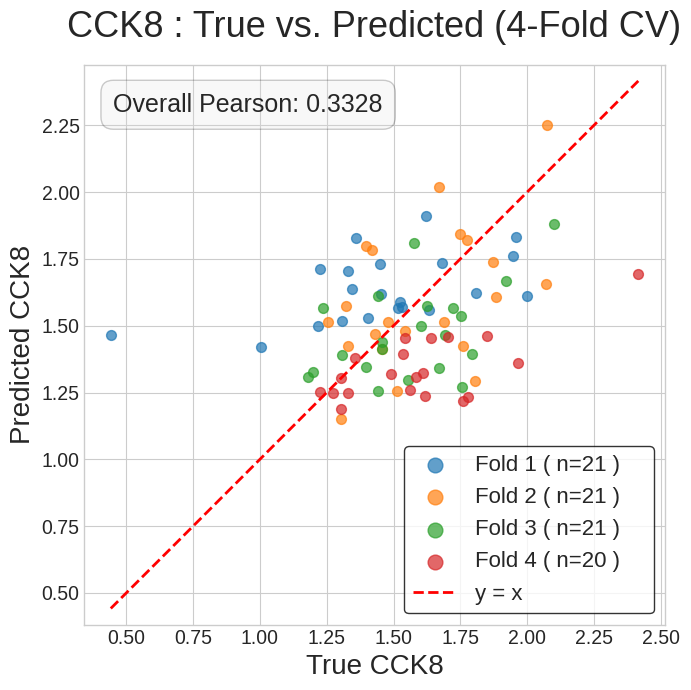

In [7]:
# 使用 'seaborn-v0_8-whitegrid' 风格
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(7,7))

# 颜色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Tableau 10 调色板

# 分别绘制每一折的散点图
for i, fold in enumerate(FOLDS):
    ax.scatter(true_scores_by_fold[fold],
               predicted_scores_by_fold[fold],
               alpha=0.7,
               color=colors[i],
               label=f'Fold {(i+1)} ( n={len(true_scores_by_fold[fold])} )    ', s=50)

# 绘制 y=x 参考线
min_val = min(min(all_true_scores), min(all_predicted_scores))
max_val = max(max(all_true_scores), max(all_predicted_scores))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y = x')

# 设置标题和标签
ax.set_title(f'{TYPE} : True vs. Predicted (4-Fold CV)', fontsize=26, pad=20)
ax.set_xlabel(f'True {TYPE}', fontsize=20)
ax.set_ylabel(f'Predicted {TYPE}', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=14)

# 将相关系数的文字框固定在左上角
ax.text(0.05, 0.95, f'Overall Pearson: {correlation:.4f}',
        transform=ax.transAxes, fontsize=18, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', fc='gainsboro', alpha=0.2))

# 设置坐标轴等长并调整布局
ax.axis('equal')
ax.grid(True)
fig.tight_layout()

# --- 修改部分 ---
# 将图例位置固定在右下角，避免与文字重叠
legend = ax.legend(loc='lower right', fontsize=16, markerscale=1.5, frameon=True, fancybox=True)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_alpha(0.8)


# 保存图像
output_plot_base = os.path.join(OUTPUT_DIR, f"{TYPE}_2")
png_path = f"{output_plot_base}.png"
pdf_path = f"{output_plot_base}.pdf"

plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, dpi=300, bbox_inches='tight')

print(f"散点图已保存至: {png_path}")
print(f"散点图已保存至: {pdf_path}")

plt.show()